In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack
import os
import tifffile
from imageio.v2 import imread

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn, fftshift

def check_striping_3d(volume):
    """
    Computes 3D FFT and displays central frequency slices to identify striping.

    Args:
        volume: 3D numpy array (Z, Y, X) - A single 3D timepoint.
    """
    # 1. Compute 3D FFT
    # This transforms the entire (z, y, x) volume into (kz, ky, kx) frequency space
    f_vol = fftn(volume)

    # 2. Shift zero frequency to center of the volume
    f_shift = fftshift(f_vol)

    # 3. Compute Log-Magnitude Spectrum
    magnitude = 20 * np.log(np.abs(f_shift) + 1)

    # 4. Extract Central Slices for Visualization
    # We look at the "planes" passing through the DC component (center)
    z_center, y_center, x_center = [s // 2 for s in volume.shape]

    freq_xy = magnitude[z_center, :, :] # Frequency content in XY plane
    freq_xz = magnitude[:, y_center, :] # Frequency content in XZ plane
    freq_yz = magnitude[:, :, x_center] # Frequency content in YZ plane

    # 5. Plotting
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Row 1: Spatial MIPs (Visual Check)
    axes[0, 0].imshow(np.max(volume, axis=0), cmap='gray')
    axes[0, 0].set_title('Spatial MIP (XY)')

    axes[0, 1].imshow(np.max(volume, axis=1), cmap='gray', aspect='auto')
    axes[0, 1].set_title('Spatial MIP (XZ)')

    axes[0, 2].imshow(np.max(volume, axis=2), cmap='gray', aspect='auto')
    axes[0, 2].set_title('Spatial MIP (YZ)')

    # Row 2: Frequency Central Slices (The Diagnostic)
    # Note: In FFT plots, the center is low freq (structure), edges are high freq (noise/stripes)
    axes[1, 0].imshow(freq_xy, cmap='inferno')
    axes[1, 0].set_title('FFT Slice (k_x, k_y)')

    axes[1, 1].imshow(freq_xz, cmap='inferno', aspect='auto')
    axes[1, 1].set_title('FFT Slice (k_x, k_z)')

    axes[1, 2].imshow(freq_yz, cmap='inferno', aspect='auto')
    axes[1, 2].set_title('FFT Slice (k_y, k_z)')

    plt.tight_layout()
    plt.show()

In [8]:
data_root = "/mnt/aquila/ssd_processing/Data2601-/MOSAIC_Data/Processed_Data/20260204 Andre 3 color Training Data/Sample 1/1"
sample = os.listdir(data_root)[0]

In [9]:
sample

'Scan_Iter_0000_0000_0017_488nm_stack0000_0000000msec_0009868647msecAbs_processed.tif'

In [10]:
# read the tif file
tif_path = os.path.join(data_root, sample)
data = imread(tif_path)

In [17]:
data_cropped = data[data.shape[0], data.shape[1]//2-256:data.shape[1]//2+256, data.shape[2]//2-256:data.shape[2]//2+256]

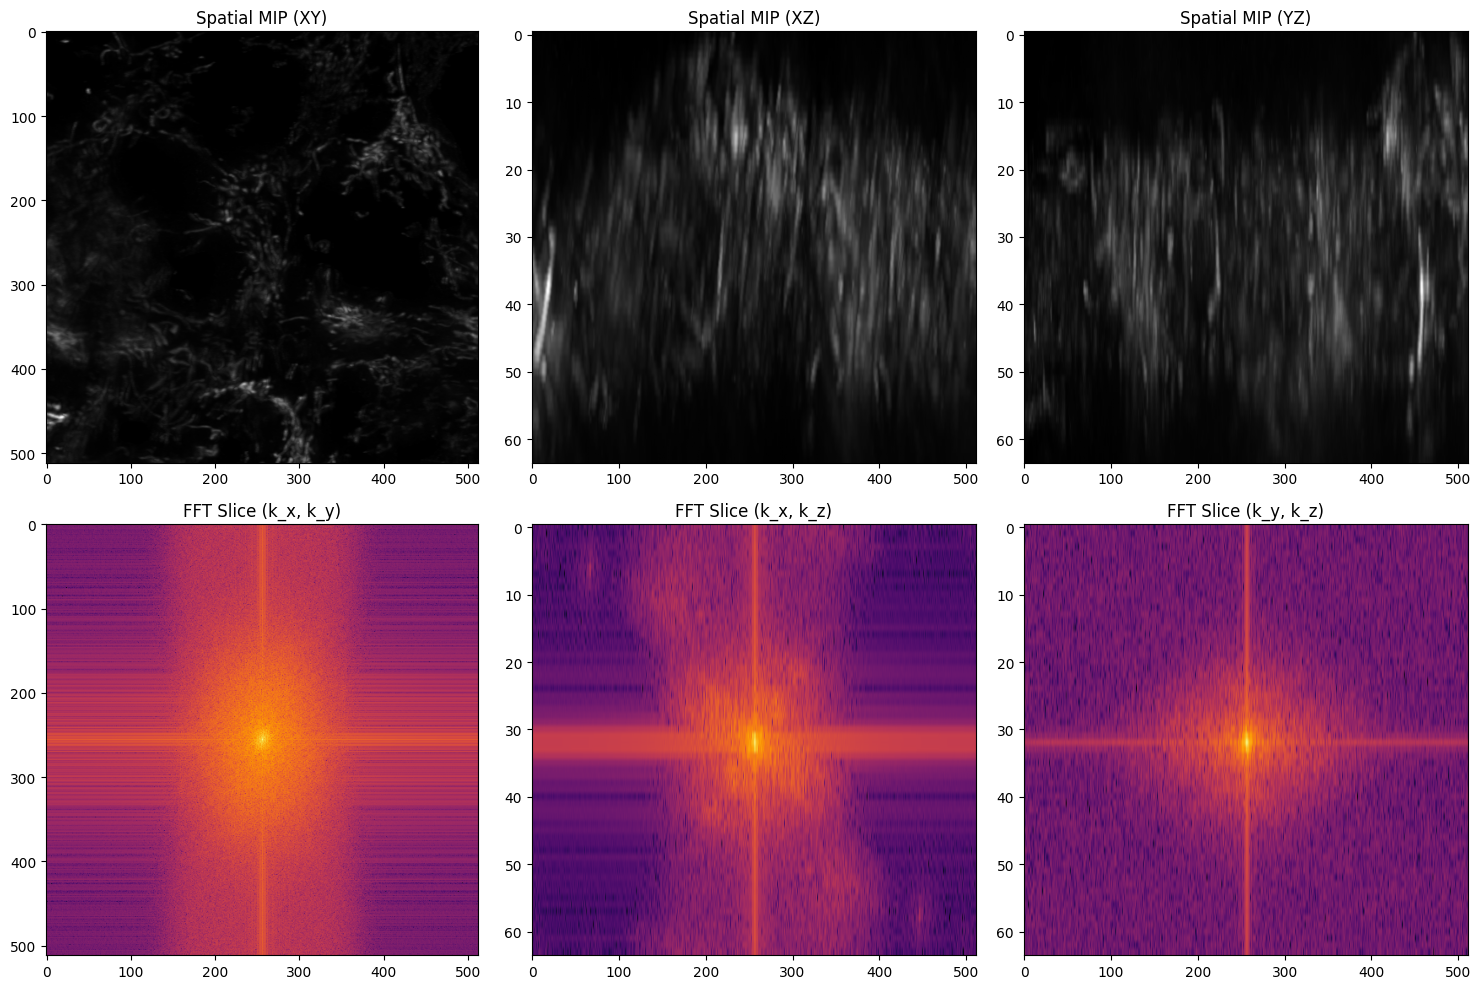

In [18]:
check_striping_3d(data_cropped)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift

def check_striping_mip(volume):
    """
    Detects striping artifacts by computing 2D FFTs on Maximum Intensity Projections (MIPs).

    Args:
        volume: 3D numpy array (Z, Y, X) - e.g., (214, 1536, 6806)
    """
    print(f"Processing volume of shape {volume.shape}...")

    # --- Step 1: Compute MIPs (Collapsing Dimensions) ---
    # This is fast and reduces memory usage drastically for the FFT step.

    # MIP along Z (Top-down view): Result is (Y, X) -> (1536, 6806)
    print("Computing MIP along Z-axis...")
    mip_xy = np.max(volume, axis=0)

    # MIP along Y (Side view): Result is (Z, X) -> (214, 6806)
    print("Computing MIP along Y-axis...")
    mip_xz = np.max(volume, axis=1)

    # --- Step 2: Compute 2D FFTs of the MIPs ---

    def compute_spectrum(image):
        f = fft2(image)
        f_shift = fftshift(f)
        # Add 1 to avoid log(0)
        magnitude = 20 * np.log(np.abs(f_shift) + 1)
        return magnitude

    print("Computing FFT of XY MIP...")
    fft_xy = compute_spectrum(mip_xy)

    print("Computing FFT of XZ MIP...")
    fft_xz = compute_spectrum(mip_xz)

    # --- Step 3: Visualization ---

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Top Row: XY Plane (Standard View)
    axes[0, 0].imshow(mip_xy, cmap='gray', vmin=np.percentile(mip_xy, 1), vmax=np.percentile(mip_xy, 99))
    axes[0, 0].set_title(f'Spatial MIP (XY)\nShape: {mip_xy.shape}')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(fft_xy, cmap='inferno')
    axes[0, 1].set_title('FFT Magnitude (XY)\nLook for: Vertical/Horizontal Lines')
    axes[0, 1].axis('off')

    # Bottom Row: XZ Plane (Side View - Critical for Light Sheet)
    # Note: Aspect ratio is set to 'auto' because Z (214) is much smaller than X (6806)
    axes[1, 0].imshow(mip_xz, cmap='gray', aspect='auto', vmin=np.percentile(mip_xz, 1), vmax=np.percentile(mip_xz, 99))
    axes[1, 0].set_title(f'Spatial MIP (XZ)\nShape: {mip_xz.shape}')
    axes[1, 0].set_xlabel('X Axis (6806)')
    axes[1, 0].set_ylabel('Z Axis (214)')

    axes[1, 1].imshow(fft_xz, cmap='inferno', aspect='auto')
    axes[1, 1].set_title('FFT Magnitude (XZ)\nLook for: Bright Central Lines')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Usage Example:
# Assuming 'my_data' is your (214, 1536, 6806) array
# check_striping_mip(my_data)

Processing volume of shape (214, 1536, 6806)...
Computing MIP along Z-axis...
Computing MIP along Y-axis...
Computing FFT of XY MIP...
Computing FFT of XZ MIP...


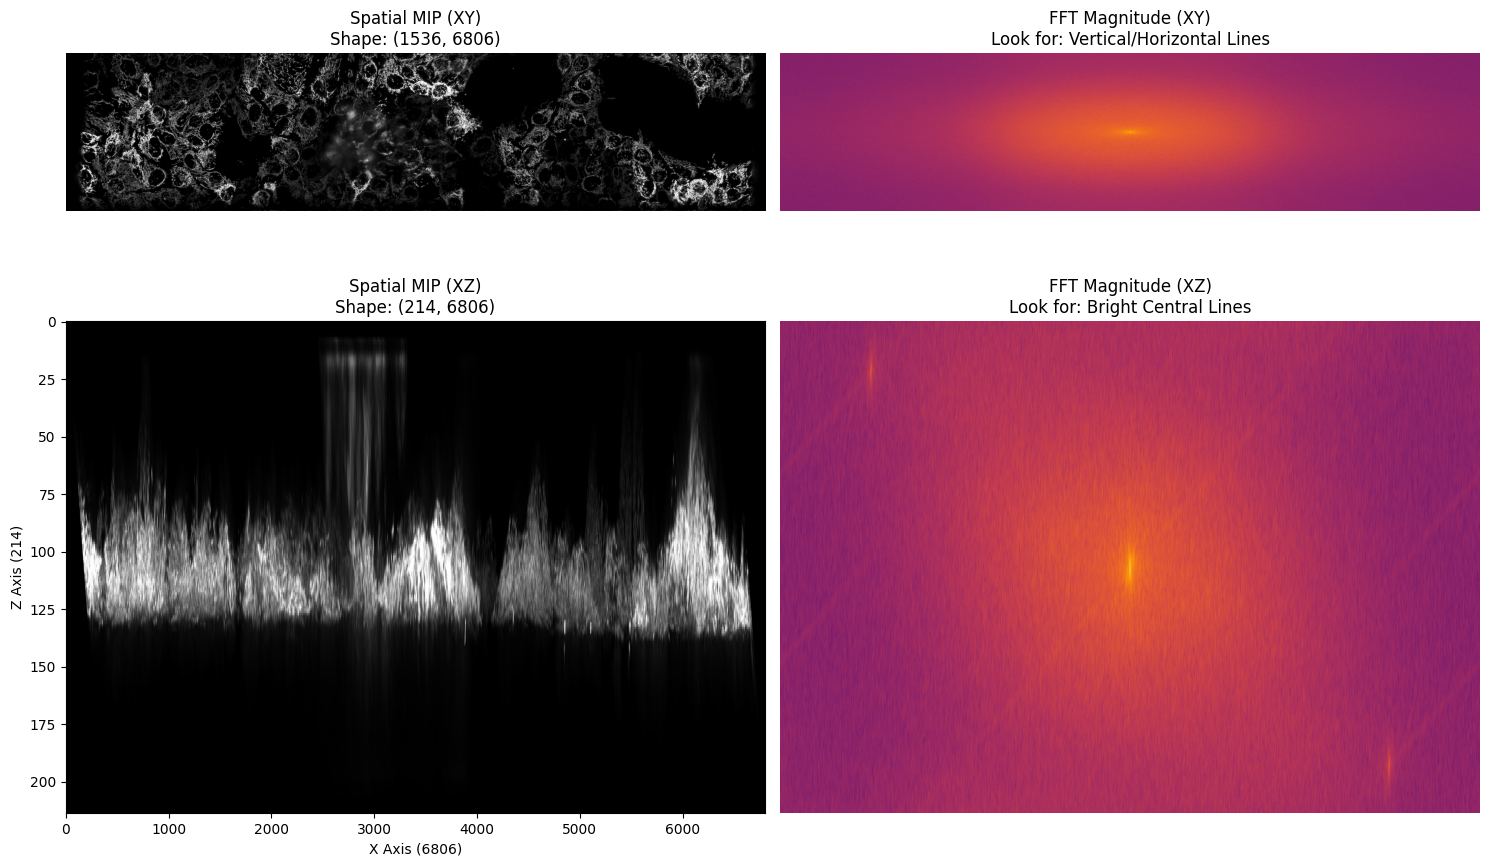

In [20]:
check_striping_mip(data)

In [21]:
import numpy as np
from scipy.ndimage import median_filter, gaussian_filter

def simple_destripe(volume, sigma=128):
    """
    Removes vertical curtaining artifacts by estimating the 'background sheet'
    profile and dividing it out.
    """
    # 1. Calculate the mean projection along Z (average intensity profile)
    # This captures the persistent vertical streaks
    z_proj = np.mean(volume, axis=0)

    # 2. Smooth this profile heavily to isolate the low-frequency illumination trends
    # (The 'sigma' should be wider than a typical cell, but smaller than the image width)
    illumination_correction = gaussian_filter(z_proj, sigma=sigma)

    # 3. Apply correction (Broadcast division)
    # We divide the volume by the 2D correction profile
    # (Adding small epsilon to avoid divide-by-zero)
    clean_volume = volume / (illumination_correction[np.newaxis, :, :] + 1e-6)

    # Rescale back to original intensity range
    clean_volume = clean_volume * np.mean(illumination_correction)

    return clean_volume.astype(volume.dtype)

In [22]:
destriped_data = simple_destripe(data)

Processing volume of shape (214, 1536, 6806)...
Computing MIP along Z-axis...
Computing MIP along Y-axis...
Computing FFT of XY MIP...
Computing FFT of XZ MIP...


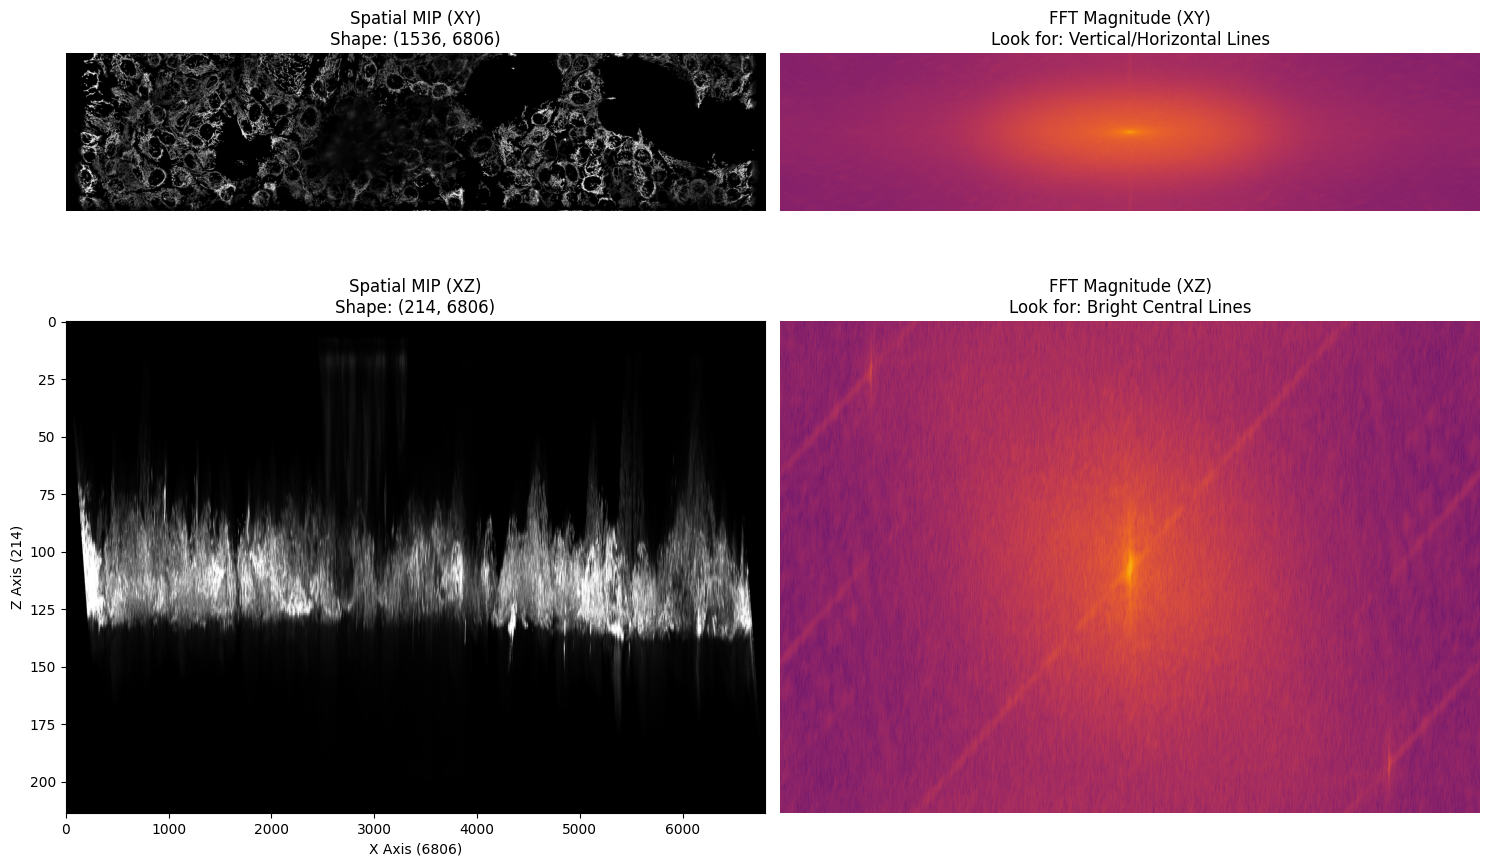

In [23]:
check_striping_mip(destriped_data)